In [1]:
# Imports

import os
import re
import hashlib
import asyncio
from dotenv import load_dotenv
from typing import TypedDict, Optional, Any, List

from langchain_core.documents import Document
from langchain_chroma import Chroma

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq

from sentence_transformers import CrossEncoder
from langgraph.graph import StateGraph, END

from transformers import pipeline
import numpy as np

load_dotenv()

True

In [2]:
# Embeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"}
)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
# Local Summarizer (FAST)

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=-1
)

print("Pipeline working")


Pipeline working


In [4]:
# LLM (only for important summaries and agent routing/answering)

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [5]:
# Constitution Vector DB (Persistent)

DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

constitution_db = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings,
    collection_name="constitution_collection"
)

In [6]:
# Summary Cache

summary_cache = {}

def hash_text(text):
    return hashlib.md5(text.encode()).hexdigest()

In [7]:
# Fast Batch Summaries

def get_fast_summary(text_list):
    summaries = summarizer(
        text_list,
        max_length=30,
        min_length=10,
        do_sample=False
    )
    return [s['summary_text'] for s in summaries]

In [8]:
# Hierarchical Splitting (Async)

async def hierarchical_split_documents(docs, doc_type="uploaded_document"):
    # Standard splitting
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
    chunks = splitter.split_documents(docs)
    
    for i, chunk in enumerate(chunks):
        chunk.metadata.update({"level": "chunk", "chunk_index": i, "doc_type": doc_type})

    # 1. Paragraph summaries (Fast/Local)
    texts = [c.page_content for c in chunks]
    summaries = get_fast_summary(texts) 
    paragraph_docs = [Document(page_content=s, metadata={"level": "para", "chunk_index": i, "doc_type": doc_type}) 
                      for i, s in enumerate(summaries)]

    # 2. Section summaries
    section_tasks = []
    section_size = 5
    
    async def get_sec_sum(text, start, end):
        res = await llm.ainvoke(f"Summarize this legal section: {text}")
        return Document(page_content=res.content, 
                        metadata={"level": "section_summary", "start_chunk": start, "end_chunk": end, "doc_type": doc_type})

    for i in range(0, len(chunks), section_size):
        group_text = "\n".join([c.page_content for c in chunks[i:i+section_size]])
        section_tasks.append(get_sec_sum(group_text, i, i + section_size))

    section_docs = await asyncio.gather(*section_tasks)
    
    return chunks + paragraph_docs + list(section_docs)

In [9]:
# Load and Prepare Uploaded Document (Ephemeral Store)

from langchain_community.document_loaders import PyMuPDFLoader

async def prepare_uploaded_document(path):
    print(f"--- Indexing Document: {os.path.basename(path)} ---")
    
    loader = PyMuPDFLoader(path)
    docs = loader.load()
    
    processed_docs = await hierarchical_split_documents(docs, doc_type="user_doc")
    
    vector_store = Chroma.from_documents(
        documents=processed_docs,
        embedding=embeddings,
        collection_name="temp_upload_collection" # Ephemeral collection
    )
    
    return vector_store

In [10]:
# Legal Retrieval (From Persistent Constitution Store)

def retrieve_legal_docs(query, k=5):
    docs = constitution_db.similarity_search(query, k=k)
    return docs

In [11]:
# Graph State

class LegalState(TypedDict):
    question: str
    strategy: Optional[str]

    legal_docs: Optional[List[Document]]
    document_docs: Optional[List[Document]]
    final_docs: Optional[List[Document]]

    answer: Optional[str]
    critique: Optional[str]

    graph_vector_store: Optional[Any]

In [12]:
# Hierarchical Document Retrieval

def retrieve_document_docs(vector_store, query, k=10):
    if vector_store is None:
        return []

    section_docs = vector_store.similarity_search(
        query,
        k=3,
        filter={"level": "section_summary"}
    )

    all_relevant_chunks = []
    for sec in section_docs:
        start = sec.metadata.get("start_chunk", 0)
        end = sec.metadata.get("end_chunk", 0)

        chunks = vector_store.similarity_search(
            query,
            k=5,
            filter={
                "$and": [
                    {"level": "chunk"},
                    {"chunk_index": {"$gte": start}},
                    {"chunk_index": {"$lte": end}}
                ]
            }
        )
        all_relevant_chunks.extend(chunks)

    # Deduplicate based on chunk_index
    unique_chunks = {chunk.metadata.get('chunk_index'): chunk for chunk in all_relevant_chunks}
    return list(unique_chunks.values())[:k]

In [13]:
# Strategist Agent

def strategist_agent(state: LegalState):
    question = state["question"]

    prompt = f"""
Decide research strategy.

Question:
{question}

Options:
legal
document
both
"""
    strategy = llm.invoke(prompt).content.strip().lower()
    state["strategy"] = strategy
    return state

In [14]:
# Legal Agent

def legal_research_agent(state: LegalState):
    query = state["question"]
    docs = retrieve_legal_docs(query, k=8)
    
    # Ensure source tracking for Evidence Fusion and Answer Agent
    for d in docs:
        d.metadata["doc_source"] = "Indian Constitution"

    state["legal_docs"] = docs
    return state

In [15]:
# Document Agent

def document_research_agent(state: LegalState):
    question = state["question"]
    vector_store = state.get("graph_vector_store")
    
    if not vector_store:
        print("--- NO UPLOADED DOCUMENT FOUND IN STATE ---")
        state["document_docs"] = []
        return state

    docs = retrieve_document_docs(vector_store, question, k=12)
    
    # Ensure source tracking
    for d in docs:
        d.metadata["doc_source"] = "Uploaded Document"

    state["document_docs"] = docs
    print(f"--- RETRIEVED {len(state['document_docs'])} DOCS FROM UPLOADED CASE ---")
    
    return state

In [16]:
# Evidence Fusion Agent

# Initialize the Cross-Encoder for better relevance ranking
cross_encoder = CrossEncoder('BAAI/bge-reranker-base')

def evidence_fusion_agent(state: LegalState):
    legal_docs = state.get("legal_docs") or []
    document_docs = state.get("document_docs") or []

    all_docs = legal_docs + document_docs

    if not all_docs:
        state["final_docs"] = []
        return state

    query = state["question"]

    # Format pairs for the Cross-Encoder: (Query, Document Text)
    pairs = [[query, d.page_content] for d in all_docs]
    
    # Predict relevance scores
    scores = cross_encoder.predict(pairs)

    # Rank documents by highest score
    ranked = sorted(
        zip(all_docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    # Top 8 highest scoring documents combined from both sources
    top_docs = [doc for doc, score in ranked[:8]]
    state["final_docs"] = top_docs

    return state

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--BAAI--bge-reranker-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

In [17]:
# Answer Agent

def answer_agent(state: LegalState):
    docs = state.get("final_docs", [])
    
    constitution_context = ""
    document_context = ""

    # Split the contexts so the LLM understands the difference between the two
    for d in docs:
        source = d.metadata.get("doc_source", "Unknown")
        if source == "Indian Constitution":
            constitution_context += d.page_content + "\n\n"
        else:
            document_context += d.page_content + "\n\n"

    prompt = f"""
You are an expert Legal Intelligence Assistant. 
Analyze the [Uploaded Document] context below in relation to the [Indian Constitution] context provided. 
If a clause in the document conflicts with or relates to a specific Article of the Constitution, explicitly highlight that relationship.
If no document was uploaded, rely solely on the Constitution and general legal knowledge.

Question:
{state["question"]}

[Uploaded Document Context]:
{document_context if document_context else "None provided."}

[Indian Constitution Context]:
{constitution_context if constitution_context else "None provided."}
"""
    answer = llm.invoke(prompt).content
    state["answer"] = answer
    return state

In [18]:
# Critic

def critic_agent(state: LegalState):
    answer = state["answer"]
    
    critique = llm.invoke(
        f"Critique this legal answer. Ensure it accurately reflects Indian Constitutional law:\n{answer}"
    ).content
    
    state["critique"] = critique
    return state

In [19]:
# Planner Workflow

workflow = StateGraph(LegalState)

# Add Nodes
workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal_research", legal_research_agent)
workflow.add_node("document_research", document_research_agent)
workflow.add_node("evidence_fusion", evidence_fusion_agent)
workflow.add_node("answer", answer_agent)
workflow.add_node("critic", critic_agent)

workflow.set_entry_point("strategist")

# Conditional Router Logic
def planner_router(state: LegalState) -> List[str]:
    strategy = state.get("strategy", "both").lower()
    
    if "both" in strategy:
        # LangGraph will fan out and run these two concurrently
        return ["legal_research", "document_research"]
    elif "legal" in strategy:
        return ["legal_research"]
    else:
        return ["document_research"]

# Add Conditional Edges
workflow.add_conditional_edges("strategist", planner_router)

# Fan in: Both research nodes feed directly into the fusion node
workflow.add_edge("legal_research", "evidence_fusion")
workflow.add_edge("document_research", "evidence_fusion")

# Linear finish
workflow.add_edge("evidence_fusion", "answer")
workflow.add_edge("answer", "critic")
workflow.add_edge("critic", END)

# Compile Graph
legal_graph = workflow.compile()

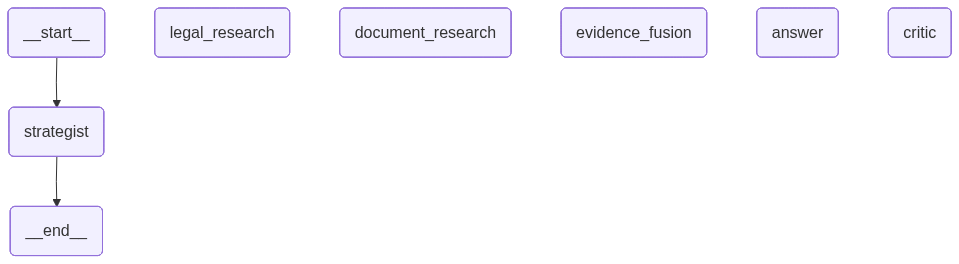

In [20]:
# Graph Visualization

from IPython.display import Image, display

try:
    # This will generate and display a PNG of your agentic workflow
    display(Image(legal_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not generate graph image: {e}")

In [21]:
# Main RAG Entry Function

async def legal_agentic_rag(question: str, uploaded_file_path: Optional[str] = None):
    vector_store = None
    
    # 1. If a document is uploaded, process it into the ephemeral vector store
    if uploaded_file_path:
        # Await the async document preparation function we defined earlier
        vector_store = await prepare_uploaded_document(uploaded_file_path)
        
    # 2. Initialize the state for LangGraph
    initial_state = {
        "question": question,
        "graph_vector_store": vector_store
    }
    
    # 3. Invoke the compiled graph
    print(f"--- Running Legal Agentic RAG for: '{question}' ---")
    result = legal_graph.invoke(initial_state)
    
    # 4. Return the final generated answer
    return result.get("answer", "No answer generated.")

In [22]:
# Execution Helper Function

def run_legal_query(question: str, uploaded_vector_store=None):
    print(f"--- Processing Query: '{question}' ---")
    
    # Initialize the state
    initial_state = {
        "question": question,
        "graph_vector_store": uploaded_vector_store
    }
    
    # Stream the graph execution to see the agent steps
    for output in legal_graph.stream(initial_state):
        for node_name, state_update in output.items():
            print(f"\n[{node_name.upper()}]:")
            
            # Print routing decision if we are at the strategist
            if node_name == "strategist":
                print(f"Strategy chosen: {state_update.get('strategy', 'unknown')}")
            
            # Print retrieved document counts
            if node_name == "legal_research":
                print(f"Retrieved {len(state_update.get('legal_docs', []))} docs from Constitution.")
            if node_name == "document_research":
                print(f"Retrieved {len(state_update.get('document_docs', []))} docs from Upload.")
                
            # Print the final fusion count
            if node_name == "evidence_fusion":
                print(f"Fused down to top {len(state_update.get('final_docs', []))} most relevant chunks.")

    # Fetch the final state after the graph finishes
    final_state = legal_graph.invoke(initial_state)
    
    print("\n" + "="*50)
    print("FINAL ANSWER:")
    print("="*50)
    print(final_state.get("answer", "No answer generated."))
    
    print("\n" + "="*50)
    print("CRITIQUE:")
    print("="*50)
    print(final_state.get("critique", "No critique generated."))
    
    return final_state

In [ ]:
# Test 1: Querying ONLY the Constitution Knowledge Base

question_1 = "What are the fundamental rights regarding freedom of speech under the Indian Constitution, and are there any reasonable restrictions?"

# Notice we pass None for the vector store
result_1 = legal_agentic_rag(question_1, uploaded_vector_store=None)

--- Processing Query: 'What are the fundamental rights regarding freedom of speech under the Indian Constitution, and are there any reasonable restrictions?' ---

[STRATEGIST]:
Strategy chosen: to answer the question about the fundamental rights regarding freedom of speech under the indian constitution and the presence of any reasonable restrictions, the most appropriate research strategy would involve consulting both legal and document sources.

1. **legal**: this involves looking into the legal framework that governs freedom of speech in india. the primary source would be article 19 of the indian constitution, which deals with the protection of certain rights regarding freedom of speech and expression. understanding the legal interpretations and judgments related to this article, as provided by the indian judiciary, especially the supreme court, would be crucial.

2. **document**: refers to the examination of official documents, academic papers, and historical records that provide in

InvalidUpdateError: At key 'question': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [ ]:
# Test 2: Querying with a specific uploaded case or contract
# Make sure to run this cell using asyncio syntax if you are in a Jupyter environment

import asyncio

async def test_uploaded_document():
    # Provide the path to a test PDF
    sample_pdf_path = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\data\Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF" 
    
    # 1. Create the ephemeral vector store for this specific document
    try:
        temp_vector_store = await prepare_uploaded_document(sample_pdf_path)
        print("Document indexed successfully.")
        
        # 2. Ask a question that requires both the document and the constitution
        question_2 = "Does the arbitration clause in this contract violate any provisions of the Indian Constitution?"
        
        # 3. Run the graph, passing in the temporary vector store
        result_2 = run_legal_query(question_2, uploaded_vector_store=temp_vector_store)
        
    except FileNotFoundError:
        print(f"Please place a PDF named '{sample_pdf_path}' in your directory to run this test.")

# Execute the async test function
await test_uploaded_document()

--- Indexing Document: Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF ---
